# Importing file

In [44]:
import pandas as pd
df = pd.read_csv("../data/Crypto_historical_data.csv", parse_dates=["Date"], index_col="Date")
df.head()
df['ticker'].value_counts() 


ticker
WETH-USD         17076
USDT-USD          5826
DOGE-USD          5826
USDC-USD          5160
WBTC-USD          4932
                 ...  
2Z-USD              29
USDAI-USD           28
USDT0-USD           28
SYRUPUSDC-USD       15
OUSG-USD             8
Name: count, Length: 213, dtype: int64

# selecting Bitcoin fron 250 coins

array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>], dtype=object)

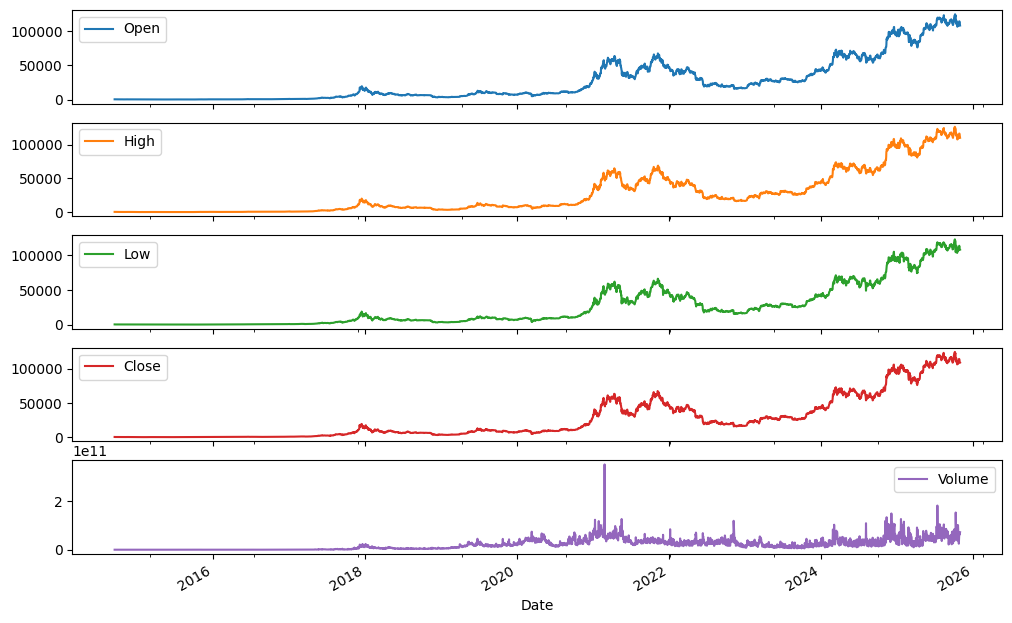

In [45]:
coin = "BTC-USD"
coin_df = df[df['ticker']==coin].sort_index()
coin_df = coin_df[['Open','High','Low','Close','Volume']].dropna()
coin_df.plot(subplots=True, figsize=(12,8))


# Preprocessing the data and feature scaling

In [46]:
import numpy as np
def create_features(df, lags=[1,2,3,5,10], windows=[3,7,14]):
    X = pd.DataFrame(index=df.index)
    X['close'] = df['Close']
    X['log_ret'] = np.log(df['Close']).diff()
    for l in lags:
        X[f'lag_{l}'] = df['Close'].shift(l)
    for w in windows:
        X[f'rolling_mean_{w}'] = df['Close'].rolling(w).mean()
        X[f'rolling_std_{w}'] = df['Close'].rolling(w).std()
        X[f'rolling_max_{w}'] = df['Close'].rolling(w).max()
    X['vol_mean_7'] = df['Volume'].rolling(7).mean()
    X = X.dropna()
    return X


In [47]:
X = create_features(coin_df)
y = coin_df['Close'].shift(-1).loc[X.index] 
X = X.iloc[:-1]
y = y.iloc[:-1]


# Splitting data for training

In [48]:
n = len(X)
train_end = int(n*0.8)
X_train, X_val = X.iloc[:train_end], X.iloc[train_end:]
y_train, y_val = y.iloc[:train_end], y.iloc[train_end:]


In [49]:
y_pred_naive = X_val['lag_1']  # predict yesterday's close
from sklearn.metrics import mean_absolute_error
print("Naive MAE:", mean_absolute_error(y_val, y_pred_naive))


Naive MAE: 1806.9751398533951


# Random forest

In [50]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_val)
print("MAE:", mean_absolute_error(y_val, y_pred))

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("RMSE:", rmse)


MAE: 17977.104300915234
RMSE: 26751.936707781555


# XGBOOST

In [51]:
import xgboost as xgb
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
params = {"objective":"reg:squarederror", "learning_rate":0.05, "max_depth":6, "seed":42}
bst = xgb.train(params, dtrain, num_boost_round=1000, evals=[(dval,"val")], early_stopping_rounds=50, verbose_eval=50)
y_pred_xgb = bst.predict(dval)


[0]	val-rmse:64796.01264
[50]	val-rmse:30864.57669
[100]	val-rmse:27838.34502
[150]	val-rmse:27671.08171
[200]	val-rmse:27708.65569
[201]	val-rmse:27708.01611


# LSTM (sequence model) Trial

In [52]:
import numpy as np
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  

seq_len = 30  
def make_sequences(X_arr, y_arr, seq_len):
    Xs, ys = [], []
    for i in range(len(X_arr) - seq_len):
        Xs.append(X_arr[i:i+seq_len])
        ys.append(y_arr[i+seq_len])
    return np.array(Xs), np.array(ys)

X_arr = X_scaled
y_arr = y.values
X_seq, y_seq = make_sequences(X_arr, y_arr, seq_len)

# train/val split
split = int(len(X_seq)*0.8)
X_tr, X_va = X_seq[:split], X_seq[split:]
y_tr, y_va = y_seq[:split], y_seq[split:]

# build LSTM
import tensorflow as tf
from tensorflow.keras import layers, models
model = models.Sequential([
    layers.Input(shape=(seq_len, X_tr.shape[2])),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=50, batch_size=64)


Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 453123680.0000 - mae: 13995.5459 - val_loss: 6353773056.0000 - val_mae: 74568.4766
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 452983936.0000 - mae: 13990.1621 - val_loss: 6353433600.0000 - val_mae: 74566.1875
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 452929280.0000 - mae: 13988.2178 - val_loss: 6353166336.0000 - val_mae: 74564.4062
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 452880320.0000 - mae: 13986.4639 - val_loss: 6352909312.0000 - val_mae: 74562.6719
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 452832608.0000 - mae: 13984.7695 - val_loss: 6352659456.0000 - val_mae: 74561.0000
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 452785824.0000 - mae: 13983.0791 - val_loss: 6352407552.0000 - val_mae: 74559.3125
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 452739680.0000 - mae: 13981.4336 - val_loss: 6352165376.0000 - val_mae: 74557.6953
Epoch 

In [3]:
import pandas as pd

hist_df = pd.DataFrame(history)
hist_df['epoch'] = range(1, len(hist_df) + 1)


NameError: name 'history' is not defined

MAE: 32972.335864668785


<Axes: xlabel='Date'>

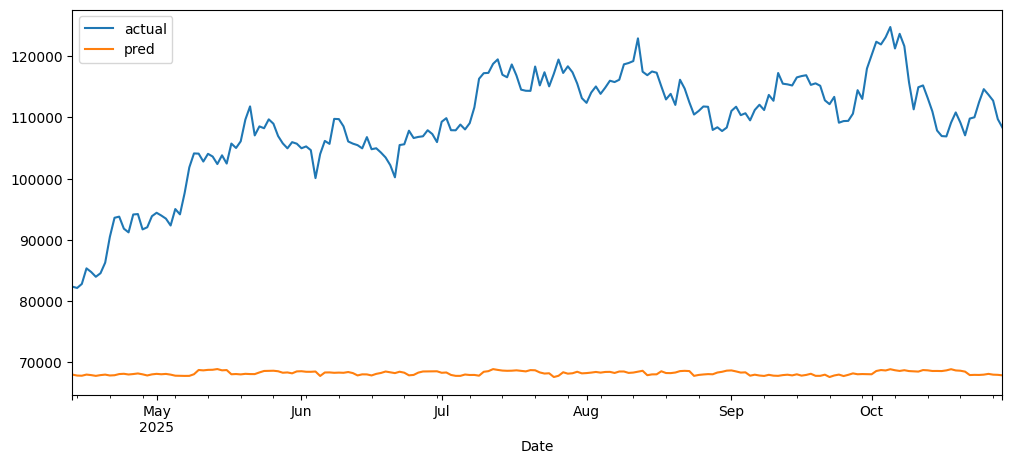

In [54]:
# RandomForest
import pandas as pd, numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
df = pd.read_csv("../data/Crypto_historical_data.csv", parse_dates=['Date'], index_col='Date')
coin_df = df[df['ticker']=='TBTC-USD'][['Close','Open','High','Low','Volume']].sort_index().dropna()
X = create_features(coin_df)   # paste the create_features function above
y = coin_df['Close'].shift(-1).loc[X.index].iloc[:-1]; X = X.iloc[:-1]
split = int(len(X)*0.8)
X_train,X_val = X.iloc[:split], X.iloc[split:]
y_train,y_val = y.iloc[:split], y.iloc[split:]
rf = RandomForestRegressor(n_estimators=300, max_depth=12, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
pred = rf.predict(X_val)
print("MAE:", mean_absolute_error(y_val,pred))
pd.DataFrame({"actual": y_val, "pred": pred}).iloc[-200:].plot(figsize=(12,5))
